# FMI weather data query sanity check
#### The method of how this sanity check was performed is as follows:
FMI publishes historical observation data, but it does not publish historical forecast data from the HARMONIE weather model. This HARMONIE model is a mathematical or numerical weather prediction model that can be used to predict weather at any given coordinates where the model is applicaple. This can be used to get a rough estimate of the weather conditions at a ships current location when the ships coordinates are fed to the weather model.

So since FMI doesn't publish historical forecast data from the HARMONIE model, it has to be done manually. For this a script was implemented that, once per hour, automatically stores forecast data from 42 handpicked coastal weather stations and loads it into a PostgreSQL database. From this database the forecast data can be used for comparison with FMIs historical observations data from those same 42 weather stations.

This comparison should give a rough estimate of how much error can be expected when querying for weather conditions at a ships location. 

#### A rough sketch of how the whole thing works:
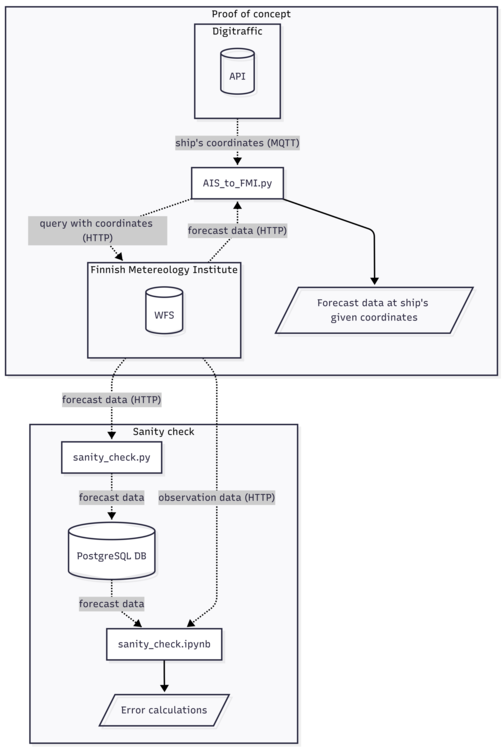

#### An illustration of the locations of the 42 weather stations used for querying data.
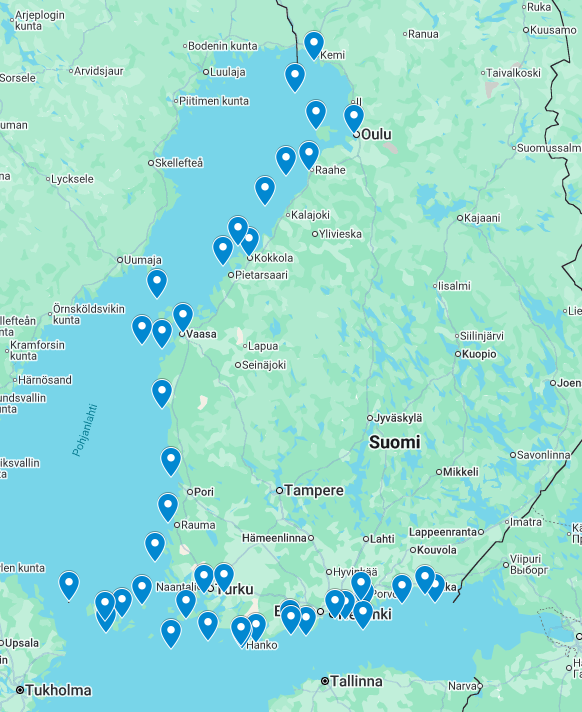

### Fetching collected and stored forecast data from PostgreSQL.
In this section forecast data that has been collected from FMI and loaded into Postgres is fetched for doing a comparison with the observation data.

In [1]:
import psycopg
import pandas as pd
from fmiopendata.wfs import download_stored_query
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
conn = psycopg.connect(
    host="localhost",
    dbname="weather",
    user=os.getenv("PSQL_USER"),
    password=os.getenv("PSQL_PASSWORD")
)
cursor = conn.cursor()

In [4]:
forecasts_df = pd.read_sql(
    """SELECT forecasts.forecast_time, forecasts.fmisid, stations.name,
    forecasts.air_pressure, forecasts.air_temperature, forecasts.humidity,
    forecasts.wind_speed, forecasts.wind_direction, forecasts.precipitation_amount,
    forecasts.total_cloud_cover, forecasts.visibility
    FROM forecasts
    INNER JOIN stations ON forecasts.fmisid=stations.fmisid
    ;""",
    conn
)

/tmp/ipykernel_28253/2526240131.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  forecasts_df = pd.read_sql(


In [5]:
forecasts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   forecast_time         504 non-null    datetime64[us]
 1   fmisid                504 non-null    int64         
 2   name                  504 non-null    str           
 3   air_pressure          504 non-null    float64       
 4   air_temperature       504 non-null    float64       
 5   humidity              504 non-null    float64       
 6   wind_speed            504 non-null    float64       
 7   wind_direction        504 non-null    float64       
 8   precipitation_amount  504 non-null    float64       
 9   total_cloud_cover     504 non-null    float64       
 10  visibility            504 non-null    float64       
dtypes: datetime64[us](1), float64(8), int64(1), str(1)
memory usage: 43.4 KB


In [6]:
oldest_forecast_time = forecasts_df["forecast_time"].min()
newest_forecast_time = forecasts_df["forecast_time"].max()

### Fetching historical observation data directly from FMIs API.

In [7]:
# These are the parameters that are to be compared with the parameters of the forecast data.
params = "p_sea,t2m,rh,ws_10min,wd_10min,r_1h,n_man,vis"

In [8]:
obs = download_stored_query(
    "fmi::observations::weather::multipointcoverage",
    args=[
        "fmisid=101042", # These are the IDs for each weather station
        "fmisid=101030",
        "fmisid=101039",
        "fmisid=101023",
        "fmisid=101022",
        "fmisid=100683",
        "fmisid=105392",
        "fmisid=100996",
        "fmisid=100997",
        "fmisid=108020",
        "fmisid=100969",
        "fmisid=100953",
        "fmisid=100932",
        "fmisid=100946",
        "fmisid=100945",
        "fmisid=100908",
        "fmisid=100924",
        "fmisid=100947",
        "fmisid=100934",
        "fmisid=100928",
        "fmisid=151048",
        "fmisid=100909",
        "fmisid=151029",
        "fmisid=100919",
        "fmisid=101059",
        "fmisid=101061",
        "fmisid=101267",
        "fmisid=101256",
        "fmisid=101479",
        "fmisid=101481",
        "fmisid=101485",
        "fmisid=101464",
        "fmisid=101660",
        "fmisid=101675",
        "fmisid=101661",
        "fmisid=101673",
        "fmisid=101775",
        "fmisid=101785",
        "fmisid=101784",
        "fmisid=101794",
        "fmisid=101783",
        "fmisid=101846",
        "starttime=" + str(oldest_forecast_time),
        "endtime=" + str(newest_forecast_time),
        "parameters=" + params,
        "timestep=60"
    ]
)

In [9]:
rows = [
    {"time": ts, "station": station, **{p: v["value"] for p, v in params.items()}}
    for ts, stations in obs.data.items()
    for station, params in stations.items()
]

obs_df = pd.DataFrame(rows).sort_values(["station", "time"])

### As can be seen below, the observational data has quite a bit of null values, probably because some stations are having issues or don't possess a particular sensor. Compare this to the forecast data which in turn possesses 0 empty values.

In [10]:
obs_df.isna().sum()

time                        0
station                     0
Pressure (msl)            869
Air temperature             3
Relative humidity           5
Wind speed                304
Wind direction            304
Precipitation amount     4608
Cloud amount             3601
Horizontal visibility    3313
dtype: int64

In [11]:
forecasts_df.isna().sum()

forecast_time           0
fmisid                  0
name                    0
air_pressure            0
air_temperature         0
humidity                0
wind_speed              0
wind_direction          0
precipitation_amount    0
total_cloud_cover       0
visibility              0
dtype: int64

### Here the observations and forecast tables are merged so calculating error becomes a bit easier.

In [12]:
merged_df = obs_df.merge(
    forecasts_df, 
    left_on=["time", "station"],
    right_on=["forecast_time", "name"],
    suffixes=("_obs", "_fcst")
)

In [13]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   time                   504 non-null    datetime64[us]
 1   station                504 non-null    str           
 2   Pressure (msl)         431 non-null    float64       
 3   Air temperature        503 non-null    float64       
 4   Relative humidity      503 non-null    float64       
 5   Wind speed             479 non-null    float64       
 6   Wind direction         479 non-null    float64       
 7   Precipitation amount   120 non-null    float64       
 8   Cloud amount           203 non-null    float64       
 9   Horizontal visibility  227 non-null    float64       
 10  forecast_time          504 non-null    datetime64[us]
 11  fmisid                 504 non-null    int64         
 12  name                   504 non-null    str           
 13  air_pressure    

In [14]:
merged_df.head(5)

,time,station,Pressure (msl),Air temperature,Relative humidity,Wind speed,Wind direction,Precipitation amount,Cloud amount,Horizontal visibility,...,fmisid,name,air_pressure,air_temperature,humidity,wind_speed,wind_direction,precipitation_amount,total_cloud_cover,visibility
0,2026-04-28 11:00:00,Hailuoto Marjaniemi,1023.3,3.2,64.0,11.3,354.0,NaN,7.0,20000.0,...,101784,Hailuoto Marjaniemi,1023.4,2.6,71.3,6.74,350.0,0.0,7.5,60594.3
1,2026-04-28 12:00:00,Hailuoto Marjaniemi,1023.5,3.4,62.0,10.2,353.0,NaN,4.0,20000.0,...,101784,Hailuoto Marjaniemi,1023.5,2.8,69.9,6.45,345.0,0.0,5.1,62940.0
2,2026-04-28 13:00:00,Hailuoto Marjaniemi,1023.6,3.8,62.0,10.3,2.0,NaN,6.0,20000.0,...,101784,Hailuoto Marjaniemi,1023.8,2.8,70.6,6.50,343.0,0.0,26.0,61863.4
3,2026-04-28 14:00:00,Hailuoto Marjaniemi,1023.9,3.4,67.0,8.7,360.0,NaN,7.0,20000.0,...,101784,Hailuoto Marjaniemi,1023.8,3.0,69.6,6.29,348.0,0.0,9.2,63565.3
4,2026-04-29 09:00:00,Hailuoto Marjaniemi,1024.9,2.5,52.0,3.8,322.0,NaN,0.0,20000.0,...,101784,Hailuoto Marjaniemi,1024.9,2.3,69.7,4.08,287.0,0.0,0.0,63231.9


### Here the actual error calculation is done using MAE or Mean Absolute Error, for now.

In [15]:
def circular_diff(a, b):
    return ((a - b + 180) % 360) - 180

In [16]:
#  MAE = Mean Absolute Error
MAE_air_pressure = (merged_df["Pressure (msl)"] - merged_df["air_pressure"]).abs().mean()
MAE_air_temperature = (merged_df["Air temperature"] - merged_df["air_temperature"]).abs().mean()
MAE_humidity = (merged_df["Relative humidity"] - merged_df["humidity"]).abs().mean()
MAE_wind_speed = (merged_df["Wind speed"] - merged_df["wind_speed"]).abs().mean()
MAE_wind_direction = circular_diff(merged_df["Wind direction"], merged_df["wind_direction"]).abs().mean()
MAE_precip_amount = (merged_df["Precipitation amount"] - merged_df["precipitation_amount"]).abs().mean()
MAE_visibility = (merged_df["Horizontal visibility"] - merged_df["visibility"]).abs().mean()

In [17]:
print(f"MAE for air pressure (msl): {round(MAE_air_pressure, 2)} hPa. Calculated from {merged_df["Pressure (msl)"].count()} rows.")
print(f"\nMAE for air temperature: {round(MAE_air_temperature, 2)} celsius. Calculated from {merged_df["Air temperature"].count()} rows.")
print(f"\nMAE for relative humidity: {round(MAE_humidity, 2)} %. Calculated from {merged_df["Relative humidity"].count()} rows.")
print(f"\nMAE for wind speed: {round(MAE_wind_speed, 2)} m/s. Calculated from {merged_df["Wind speed"].count()} rows.")
print(f"\nMAE for wind wind direction: {round(MAE_wind_direction, 2)} degrees. Calculated from {merged_df["Wind direction"].count()} rows.")
print(f"\nMAE for precipitation amount: {round(MAE_precip_amount, 5)} mm. Calculated from {merged_df["Precipitation amount"].count()} rows.")
print(f"\nMAE for horizontal visibility: {round(MAE_visibility, 2)} meters. Calculated from {merged_df["Horizontal visibility"].count()} rows.")

MAE for air pressure (msl): 0.4 hPa. Calculated from 431 rows.

MAE for air temperature: 0.96 celsius. Calculated from 503 rows.

MAE for relative humidity: 7.83 %. Calculated from 503 rows.

MAE for wind speed: 1.54 m/s. Calculated from 479 rows.

MAE for wind wind direction: 17.29 degrees. Calculated from 479 rows.

MAE for precipitation amount: 0.07992 mm. Calculated from 120 rows.

MAE for horizontal visibility: 27794.89 meters. Calculated from 227 rows.


### As can be seen from the results above, error for visibility seems to be quite high so there may be some inconsistencies in the data. Also the result for precipitation amount seems a bit dubious since there are much fewer usable rows for comparison than with other parameters and the error is suspiciously low.